# 11 · Evaluación comparativa y validación final del recomendador

Este notebook cierra la parte experimental del sistema de recomendación.

Hasta ahora se han construido los datos, calculado los tiempos de transporte, obtenido los frentes de Pareto, generado recomendaciones personalizadas y estudiado su estabilidad. En este último paso se evalúa el sistema de forma conjunta y se compara con estrategias más sencillas.

La evaluación responde a cinco preguntas:

1. ¿Aporta algo personalizar la recomendación frente a elegir siempre el barrio más barato o el más rápido?
2. ¿Las recomendaciones cumplen las restricciones de cada perfil?
3. ¿Limitar la búsqueda al frente de Pareto hace perder alguna alternativa mejor?
4. ¿El resultado cambia cuando cambian las preferencias?
5. ¿Existe variedad entre destinos y perfiles?

Se comparan cinco métodos:

- **Más barato**.
- **Más rápido**.
- **Equilibrio fijo** con pesos 50 %–50 %.
- **Búsqueda exhaustiva personalizada**, utilizada como referencia.
- **Recomendador Pareto personalizado**, que aplica restricciones, recalcula Pareto y ordena según los pesos del usuario.

La búsqueda exhaustiva permite comprobar si la reducción mediante Pareto conserva realmente la mejor solución compatible.

## 1. Importaciones

In [1]:
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from pandas.api.types import is_bool_dtype

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 180)

TOLERANCE = 1e-10
TOP_K = 5

## 2. Localización del proyecto y archivos

El notebook utiliza `data/results/pareto_by_destination.csv`, generado en el notebook 08 y reutilizado en el notebook 09. Los resultados se guardan en `data/results`.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la raíz del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PARETO_RESULTS_PATH = RESULTS_DIR / "pareto_by_destination.csv"

OUTPUT_PATHS = {
    "scenarios": RESULTS_DIR / "final_evaluation_scenarios.csv",
    "method_results": RESULTS_DIR / "final_evaluation_method_results.csv",
    "method_summary": RESULTS_DIR / "final_evaluation_method_summary.csv",
    "top5": RESULTS_DIR / "final_evaluation_top5_rankings.csv",
    "baseline_improvements": RESULTS_DIR / "final_evaluation_baseline_improvements.csv",
    "diversity": RESULTS_DIR / "final_evaluation_diversity_summary.csv",
    "profile_adaptation": RESULTS_DIR / "final_evaluation_profile_adaptation.csv",
    "validation": RESULTS_DIR / "final_evaluation_validation.csv",
}

if not PARETO_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "No existe pareto_by_destination.csv. "
        "Ejecuta primero el notebook 08."
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Entrada:", PARETO_RESULTS_PATH.relative_to(PROJECT_ROOT))
print("Resultados:", RESULTS_DIR.relative_to(PROJECT_ROOT))

Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Entrada: data\results\pareto_by_destination.csv
Resultados: data\results


## 3. Carga y validación de la entrada

In [3]:
evaluation_data = pd.read_csv(PARETO_RESULTS_PATH)

PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"
RELIABILITY_COLUMN = "price_reliability_score"

KEY_COLUMNS = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
]

REQUIRED_COLUMNS = KEY_COLUMNS + [
    PRICE_COLUMN,
    TIME_COLUMN,
    "is_pareto",
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in evaluation_data.columns
]

if missing_columns:
    raise KeyError(
        "Faltan columnas necesarias: "
        f"{missing_columns}"
    )

duplicate_pairs = evaluation_data.duplicated(
    ["zone_key", "destination_id"],
    keep=False,
)

if duplicate_pairs.any():
    display(
        evaluation_data.loc[
            duplicate_pairs,
            KEY_COLUMNS,
        ]
    )
    raise ValueError(
        "Hay combinaciones barrio–destino duplicadas."
    )

print("Dimensiones:", evaluation_data.shape)
print("Barrios:", evaluation_data["zone_key"].nunique())
print("Destinos:", evaluation_data["destination_id"].nunique())

display(evaluation_data.head())

Dimensiones: (371, 145)
Barrios: 128
Destinos: 3


,zone_key,neighborhood_name,district_name,has_real_estate_data,price_estimate_available,coverage_status,total_listings,eligible_listings,excluded_listings,eligible_percentage,excluded_percentage,market_share_percentage,num_listings,price_eur_mean,price_eur_median,price_eur_q1,price_eur_q3,price_eur_iqr,price_eur_min,price_eur_max,price_m2_mean,price_m2_median,price_m2_q1,price_m2_q3,price_m2_iqr,price_m2_std,price_m2_relative_iqr_percentage,price_m2_median_ci_low,price_m2_median_ci_high,price_m2_median_ci_width,price_m2_median_ci_relative_width_percentage,price_m2_median_bootstrap_se,bootstrap_sample_size,bootstrap_iterations,bootstrap_confidence_level,bootstrap_status,area_m2_mean,area_m2_median,area_m2_q1,area_m2_q3,area_m2_iqr,area_m2_min,area_m2_max,rooms_mean,rooms_median,rooms_known_count,rooms_unknown_count,rooms_coverage_percentage,bathrooms_mean,bathrooms_median,bathrooms_known_count,bathrooms_unknown_count,bathrooms_coverage_percentage,elevator_ratio,elevator_percentage,elevator_known_count,elevator_unknown_count,elevator_coverage_percentage,exterior_ratio,exterior_percentage,exterior_known_count,exterior_unknown_count,exterior_coverage_percentage,sample_size_score,ci_precision_score,price_homogeneity_score,price_reliability_score,price_reliability_level,price_reliability_reason,market_scope,price_type,source_snapshot_date_status,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025,registered_price_available,registered_new_price_available,registered_used_price_available,reference_year,price_unit,price_statistic,housing_market_scope,source_publisher,source_origin,source_series_code,minimum_cases_to_publish_neighborhood,source_coverage_2025_percentage,kaggle_asking_price_available,kaggle_features_available,kaggle_sample_reliability_score,kaggle_sample_reliability_level,price_m2_for_recommender,price_m2_for_recommender_source,housing_data_availability_status,registered_minus_kaggle_eur_m2,registered_vs_kaggle_gap_percentage,registered_to_kaggle_price_ratio,destination_id,neighborhood_name_transit,district_name_transit,destination_name,service_date,evening_route_status,morning_route_status,morning_start_datetime,morning_end_datetime,morning_transit_modes,morning_routes_used,morning_agencies_used,morning_duration_minutes,morning_walk_time_minutes,morning_waiting_time_minutes,morning_walk_distance_meters,morning_number_of_transfers,evening_start_datetime,evening_end_datetime,evening_transit_modes,evening_routes_used,evening_agencies_used,evening_duration_minutes,evening_walk_time_minutes,evening_waiting_time_minutes,evening_walk_distance_meters,evening_number_of_transfers,commute_daily_minutes,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_transfers,no_route_scenarios,route_status,route_available,route_missing_reason,usable_for_pareto_knn,is_pareto,dominated_by_count,price_normalized,time_normalized,distance_to_ideal,pareto_balance_rank
0,MAD-021,Imperial,Arganzuela,True,True,available,73,71,2,97.26,2.74,0.64,71,552415.49,515000.0,377000.00,699950.0,322950.00,168800.0,1257000.0,5807.42,5588.24,4756.76,6536.43,1779.68,1358.43,31.85,5443.04,5808.82,365.79,6.55,107.93,71,2000,0.95,calculated,96.25,107.0,62.50,128.00,65.50,37.0,190.0,2.62,3.0,71,0,100.00,1.82,2.0,11,60,15.49,0.8571,85.71,70,1,98.59,0.8000,80.00,70,1,98.59,56.35,92.06,47.22,68.35,medium,La estimación presenta una estabilidad intermedia en comparación con el resto de barrios.,residential_sale,asking_price,unknown,5855.12,6010.51,5776.45,110.77,119.22,108.30,100,102.65,98.66,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,504020100060,15,97.7,True,True,68.35,medium,5855.12,registered_transactions_2025,official_price_and

In [4]:
def parse_boolean_series(
    series: pd.Series,
    column_name: str,
) -> pd.Series:
    if is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    true_values = {
        "true", "1", "yes", "y", "si", "sí"
    }
    false_values = {
        "false", "0", "no", "n"
    }
    valid_values = true_values | false_values

    invalid = (
        normalized.notna()
        & ~normalized.isin(valid_values)
    )

    if invalid.any():
        examples = sorted(
            normalized.loc[invalid]
            .dropna()
            .unique()
            .tolist()
        )[:10]

        raise ValueError(
            f"Valores no reconocidos en {column_name}: "
            f"{examples}"
        )

    return normalized.isin(true_values).fillna(False)


evaluation_data["is_pareto"] = parse_boolean_series(
    evaluation_data["is_pareto"],
    "is_pareto",
)

for column in [
    PRICE_COLUMN,
    TIME_COLUMN,
    RELIABILITY_COLUMN,
    "price_normalized",
    "time_normalized",
    "dominated_by_count",
]:
    if column in evaluation_data.columns:
        evaluation_data[column] = pd.to_numeric(
            evaluation_data[column],
            errors="coerce",
        )

invalid_objectives = evaluation_data[
    evaluation_data[[PRICE_COLUMN, TIME_COLUMN]]
    .isna()
    .any(axis=1)
    | (
        evaluation_data[[PRICE_COLUMN, TIME_COLUMN]]
        <= 0
    ).any(axis=1)
]

if not invalid_objectives.empty:
    display(
        invalid_objectives[
            KEY_COLUMNS + [PRICE_COLUMN, TIME_COLUMN]
        ]
    )
    raise ValueError(
        "Existen precios o tiempos no válidos."
    )

print("La entrada ha superado las comprobaciones iniciales.")

La entrada ha superado las comprobaciones iniciales.


## 4. Escenarios de evaluación

Los perfiles se utilizan como escenarios experimentales reproducibles, no como una representación completa de todas las personas que buscan vivienda.

Los límites se calculan mediante percentiles dentro de cada destino. Así se evita fijar cifras arbitrarias que podrían ser razonables para un destino y demasiado estrictas para otro.

- **Prioridad económica**: 80 % precio y límite de precio en el percentil 60.
- **Perfil equilibrado**: pesos iguales y límites en el percentil 80.
- **Prioridad movilidad**: 80 % tiempo y límite de tiempo en el percentil 60.
- **Perfil exigente**: límites conjuntos de precio, tiempo y fiabilidad.

In [5]:
profiles = pd.DataFrame(
    [
        {
            "profile_id": "economic",
            "profile_name": "Prioridad económica",
            "price_weight": 0.80,
            "time_weight": 0.20,
            "max_price_quantile": 0.60,
            "max_time_quantile": 1.00,
            "min_reliability_quantile": 0.00,
        },
        {
            "profile_id": "balanced",
            "profile_name": "Perfil equilibrado",
            "price_weight": 0.50,
            "time_weight": 0.50,
            "max_price_quantile": 0.80,
            "max_time_quantile": 0.80,
            "min_reliability_quantile": 0.00,
        },
        {
            "profile_id": "mobility",
            "profile_name": "Prioridad movilidad",
            "price_weight": 0.20,
            "time_weight": 0.80,
            "max_price_quantile": 1.00,
            "max_time_quantile": 0.60,
            "min_reliability_quantile": 0.00,
        },
        {
            "profile_id": "demanding",
            "profile_name": "Perfil exigente",
            "price_weight": 0.50,
            "time_weight": 0.50,
            "max_price_quantile": 0.75,
            "max_time_quantile": 0.75,
            "min_reliability_quantile": 0.25,
        },
    ]
)

if not np.allclose(
    profiles["price_weight"]
    + profiles["time_weight"],
    1.0,
):
    raise ValueError(
        "Los pesos de todos los perfiles deben sumar 1."
    )

display(profiles)

,profile_id,profile_name,price_weight,time_weight,max_price_quantile,max_time_quantile,min_reliability_quantile
0,economic,Prioridad económica,0.8,0.2,0.60,1.00,0.00
1,balanced,Perfil equilibrado,0.5,0.5,0.80,0.80,0.00
2,mobility,Prioridad movilidad,0.2,0.8,1.00,0.60,0.00
3,demanding,Perfil exigente,0.5,0.5,0.75,0.75,0.25


## 5. Funciones auxiliares

La puntuación es menor cuanto mejor encaja una alternativa con el perfil. El **arrepentimiento** mide la diferencia respecto a la mejor solución compatible obtenida mediante búsqueda exhaustiva. Un valor cero indica que el método ha encontrado el óptimo del escenario.

In [6]:
def min_max_normalize(
    series: pd.Series,
) -> pd.Series:
    values = pd.to_numeric(
        series,
        errors="coerce",
    ).astype(float)

    minimum = values.min()
    maximum = values.max()

    if not np.isfinite(minimum) or not np.isfinite(maximum):
        raise ValueError(
            "No se puede normalizar una serie sin valores finitos."
        )

    if np.isclose(maximum, minimum):
        return pd.Series(
            np.zeros(len(values), dtype=float),
            index=series.index,
        )

    return (values - minimum) / (maximum - minimum)


def pareto_mask(
    data: pd.DataFrame,
    tolerance: float = TOLERANCE,
) -> pd.Series:
    values = (
        data[[PRICE_COLUMN, TIME_COLUMN]]
        .to_numpy(dtype=float)
    )

    efficient = np.ones(
        len(data),
        dtype=bool,
    )

    for index, point in enumerate(values):
        no_worse = np.all(
            values <= point + tolerance,
            axis=1,
        )
        strictly_better = np.any(
            values < point - tolerance,
            axis=1,
        )
        efficient[index] = not np.any(
            no_worse & strictly_better
        )

    return pd.Series(
        efficient,
        index=data.index,
        dtype=bool,
    )


def add_scores(
    destination_data: pd.DataFrame,
    price_weight: float,
    time_weight: float,
) -> pd.DataFrame:
    scored = destination_data.copy()

    scored["evaluation_price_normalized"] = (
        min_max_normalize(scored[PRICE_COLUMN])
    )
    scored["evaluation_time_normalized"] = (
        min_max_normalize(scored[TIME_COLUMN])
    )

    scored["personalized_score"] = (
        price_weight
        * scored["evaluation_price_normalized"]
        + time_weight
        * scored["evaluation_time_normalized"]
    )

    scored["balanced_score"] = (
        0.50
        * scored["evaluation_price_normalized"]
        + 0.50
        * scored["evaluation_time_normalized"]
    )

    return scored


def build_limits(
    destination_data: pd.DataFrame,
    profile: pd.Series,
) -> dict:
    limits = {
        "max_price_m2": float(
            destination_data[PRICE_COLUMN].quantile(
                profile["max_price_quantile"]
            )
        ),
        "max_commute_minutes": float(
            destination_data[TIME_COLUMN].quantile(
                profile["max_time_quantile"]
            )
        ),
        "min_price_reliability": np.nan,
    }

    if (
        RELIABILITY_COLUMN in destination_data.columns
        and destination_data[RELIABILITY_COLUMN]
        .notna()
        .any()
    ):
        limits["min_price_reliability"] = float(
            destination_data[RELIABILITY_COLUMN]
            .dropna()
            .quantile(
                profile["min_reliability_quantile"]
            )
        )

    return limits


def feasible_mask(
    destination_data: pd.DataFrame,
    limits: dict,
) -> pd.Series:
    mask = (
        destination_data[PRICE_COLUMN]
        <= limits["max_price_m2"] + TOLERANCE
    ) & (
        destination_data[TIME_COLUMN]
        <= limits["max_commute_minutes"] + TOLERANCE
    )

    minimum_reliability = limits[
        "min_price_reliability"
    ]

    if (
        RELIABILITY_COLUMN in destination_data.columns
        and np.isfinite(minimum_reliability)
    ):
        mask &= (
            destination_data[RELIABILITY_COLUMN]
            .fillna(-np.inf)
            >= minimum_reliability - TOLERANCE
        )

    return mask.astype(bool)


def select_first(
    data: pd.DataFrame,
    primary_columns: list[str],
) -> pd.Series:
    if data.empty:
        raise ValueError(
            "No se puede seleccionar una alternativa "
            "de un conjunto vacío."
        )

    sort_columns = primary_columns + [
        PRICE_COLUMN,
        TIME_COLUMN,
        "zone_key",
    ]

    return (
        data.sort_values(
            sort_columns,
            ascending=[True] * len(sort_columns),
            kind="mergesort",
        )
        .iloc[0]
    )


def count_dominators(
    feasible_data: pd.DataFrame,
    selected: pd.Series,
) -> int:
    no_worse_price = (
        feasible_data[PRICE_COLUMN]
        <= float(selected[PRICE_COLUMN]) + TOLERANCE
    )
    no_worse_time = (
        feasible_data[TIME_COLUMN]
        <= float(selected[TIME_COLUMN]) + TOLERANCE
    )
    strictly_better = (
        (
            feasible_data[PRICE_COLUMN]
            < float(selected[PRICE_COLUMN]) - TOLERANCE
        )
        | (
            feasible_data[TIME_COLUMN]
            < float(selected[TIME_COLUMN]) - TOLERANCE
        )
    )

    return int(
        (
            no_worse_price
            & no_worse_time
            & strictly_better
        ).sum()
    )

## 6. Ejecución del experimento

Para cada destino y perfil se aplican los cinco métodos. El frente de Pareto se recalcula después de filtrar las restricciones, ya que el conjunto eficiente puede cambiar.

In [7]:
METHOD_LABELS = {
    "cheapest": "Más barato",
    "fastest": "Más rápido",
    "fixed_balanced": "Equilibrio fijo",
    "personalized_exhaustive": "Búsqueda exhaustiva personalizada",
    "personalized_pareto": "Recomendador Pareto personalizado",
}

scenario_rows = []
method_rows = []
top5_rows = []

for (
    destination_id,
    destination_name,
), destination_group in evaluation_data.groupby(
    ["destination_id", "destination_name"],
    sort=True,
    dropna=False,
):
    destination_group = (
        destination_group.copy()
        .reset_index(drop=True)
    )

    for _, profile in profiles.iterrows():
        scored = add_scores(
            destination_group,
            price_weight=float(
                profile["price_weight"]
            ),
            time_weight=float(
                profile["time_weight"]
            ),
        )

        limits = build_limits(
            scored,
            profile,
        )

        compatible = (
            scored.loc[
                feasible_mask(scored, limits)
            ]
            .copy()
            .reset_index(drop=True)
        )

        if compatible.empty:
            raise ValueError(
                "El escenario ha quedado sin alternativas: "
                f"{destination_name} - "
                f"{profile['profile_name']}."
            )

        compatible["is_pareto_feasible"] = (
            pareto_mask(compatible)
        )

        compatible_pareto = (
            compatible.loc[
                compatible["is_pareto_feasible"]
            ]
            .copy()
        )

        exhaustive_best = select_first(
            compatible,
            ["personalized_score"],
        )
        pareto_best = select_first(
            compatible_pareto,
            ["personalized_score"],
        )

        selections = {
            "cheapest": select_first(
                scored,
                [PRICE_COLUMN],
            ),
            "fastest": select_first(
                scored,
                [TIME_COLUMN],
            ),
            "fixed_balanced": select_first(
                scored,
                ["balanced_score"],
            ),
            "personalized_exhaustive": exhaustive_best,
            "personalized_pareto": pareto_best,
        }

        scenario_id = (
            f"{destination_id}__"
            f"{profile['profile_id']}"
        )

        scenario_rows.append(
            {
                "scenario_id": scenario_id,
                "destination_id": destination_id,
                "destination_name": destination_name,
                "profile_id": profile["profile_id"],
                "profile_name": profile["profile_name"],
                "price_weight": float(
                    profile["price_weight"]
                ),
                "time_weight": float(
                    profile["time_weight"]
                ),
                "max_price_m2": limits["max_price_m2"],
                "max_commute_minutes": limits[
                    "max_commute_minutes"
                ],
                "min_price_reliability": limits[
                    "min_price_reliability"
                ],
                "alternatives_total": len(scored),
                "alternatives_feasible": len(compatible),
                "alternatives_pareto_feasible": len(
                    compatible_pareto
                ),
                "feasible_percentage": (
                    100 * len(compatible) / len(scored)
                ),
                "pareto_feasible_percentage": (
                    100
                    * len(compatible_pareto)
                    / len(compatible)
                ),
            }
        )

        oracle_score = float(
            exhaustive_best["personalized_score"]
        )

        for method_id, selected in selections.items():
            meets_price = bool(
                float(selected[PRICE_COLUMN])
                <= limits["max_price_m2"] + TOLERANCE
            )
            meets_time = bool(
                float(selected[TIME_COLUMN])
                <= limits["max_commute_minutes"] + TOLERANCE
            )

            minimum_reliability = limits[
                "min_price_reliability"
            ]
            selected_reliability = (
                selected.get(
                    RELIABILITY_COLUMN,
                    np.nan,
                )
            )

            if np.isfinite(minimum_reliability):
                meets_reliability = bool(
                    pd.notna(selected_reliability)
                    and float(selected_reliability)
                    >= minimum_reliability - TOLERANCE
                )
            else:
                meets_reliability = True

            selected_in_compatible = compatible[
                compatible["zone_key"].eq(
                    selected["zone_key"]
                )
            ]

            if selected_in_compatible.empty:
                selected_is_pareto = False
                dominators = np.nan
            else:
                selected_is_pareto = bool(
                    selected_in_compatible.iloc[0][
                        "is_pareto_feasible"
                    ]
                )
                dominators = count_dominators(
                    compatible,
                    selected,
                )

            selected_score = float(
                selected["personalized_score"]
            )

            method_rows.append(
                {
                    "scenario_id": scenario_id,
                    "destination_id": destination_id,
                    "destination_name": destination_name,
                    "profile_id": profile["profile_id"],
                    "profile_name": profile["profile_name"],
                    "method_id": method_id,
                    "method_name": METHOD_LABELS[
                        method_id
                    ],
                    "zone_key": selected["zone_key"],
                    "neighborhood_name": selected[
                        "neighborhood_name"
                    ],
                    "district_name": selected[
                        "district_name"
                    ],
                    PRICE_COLUMN: float(
                        selected[PRICE_COLUMN]
                    ),
                    TIME_COLUMN: float(
                        selected[TIME_COLUMN]
                    ),
                    RELIABILITY_COLUMN: (
                        float(selected_reliability)
                        if pd.notna(selected_reliability)
                        else np.nan
                    ),
                    "evaluation_price_normalized": float(
                        selected[
                            "evaluation_price_normalized"
                        ]
                    ),
                    "evaluation_time_normalized": float(
                        selected[
                            "evaluation_time_normalized"
                        ]
                    ),
                    "personalized_score": selected_score,
                    "oracle_score": oracle_score,
                    "regret_vs_oracle": max(
                        0.0,
                        selected_score - oracle_score,
                    ),
                    "meets_price_limit": meets_price,
                    "meets_time_limit": meets_time,
                    "meets_reliability_limit": meets_reliability,
                    "meets_all_constraints": (
                        meets_price
                        and meets_time
                        and meets_reliability
                    ),
                    "is_pareto_global": bool(
                        selected["is_pareto"]
                    ),
                    "is_pareto_feasible": selected_is_pareto,
                    "dominators_in_feasible_set": dominators,
                }
            )

        top5 = (
            compatible_pareto.sort_values(
                [
                    "personalized_score",
                    PRICE_COLUMN,
                    TIME_COLUMN,
                    "zone_key",
                ],
                kind="mergesort",
            )
            .head(TOP_K)
            .reset_index(drop=True)
        )

        for rank, (_, row) in enumerate(
            top5.iterrows(),
            start=1,
        ):
            top5_rows.append(
                {
                    "scenario_id": scenario_id,
                    "destination_id": destination_id,
                    "destination_name": destination_name,
                    "profile_id": profile["profile_id"],
                    "profile_name": profile["profile_name"],
                    "rank": rank,
                    "zone_key": row["zone_key"],
                    "neighborhood_name": row[
                        "neighborhood_name"
                    ],
                    "district_name": row[
                        "district_name"
                    ],
                    PRICE_COLUMN: float(
                        row[PRICE_COLUMN]
                    ),
                    TIME_COLUMN: float(
                        row[TIME_COLUMN]
                    ),
                    "personalized_score": float(
                        row["personalized_score"]
                    ),
                }
            )

scenario_audit = pd.DataFrame(scenario_rows)
method_results = pd.DataFrame(method_rows)
top5_results = pd.DataFrame(top5_rows)

print("Escenarios:", len(scenario_audit))
print("Resultados método–escenario:", len(method_results))
print("Filas top 5:", len(top5_results))

display(scenario_audit.head())

Escenarios: 12
Resultados método–escenario: 60
Filas top 5: 59


,scenario_id,destination_id,destination_name,profile_id,profile_name,price_weight,time_weight,max_price_m2,max_commute_minutes,min_price_reliability,alternatives_total,alternatives_feasible,alternatives_pareto_feasible,feasible_percentage,pareto_feasible_percentage
0,DEST_001__economic,DEST_001,Puerta del Sol,economic,Prioridad económica,0.8,0.2,5371.146,244.516667,1.35,119,68,10,57.142857,14.705882
1,DEST_001__balanced,DEST_001,Puerta del Sol,balanced,Perfil equilibrado,0.5,0.5,6548.184,144.056667,1.35,119,69,12,57.983193,17.391304
2,DEST_001__mobility,DEST_001,Puerta del Sol,mobility,Prioridad movilidad,0.2,0.8,14108.830,124.723333,1.35,119,70,11,58.823529,15.714286
3,DEST_001__demanding,DEST_001,Puerta del Sol,demanding,Perfil exigente,0.5,0.5,6344.525,138.283333,33.25,119,42,9,35.294118,21.428571
4,DEST_002__economic,DEST_002,Nuevos Ministerios,economic,Prioridad económica,0.8,0.2,5433.218,275.783333,1.35,124,71,8,57.258065,11.267606


## 7. Cobertura de los escenarios

,profile_id,profile_name,scenarios,alternatives_total_mean,alternatives_feasible_mean,feasible_percentage_mean,pareto_feasible_mean,pareto_feasible_percentage_mean
0,balanced,Perfil equilibrado,3,123.67,71.33,57.68,8.33,11.81
1,demanding,Perfil exigente,3,123.67,43.33,35.04,6.33,14.76
2,economic,Prioridad económica,3,123.67,71.00,57.40,7.67,10.91
3,mobility,Prioridad movilidad,3,123.67,72.00,58.23,8.00,11.19


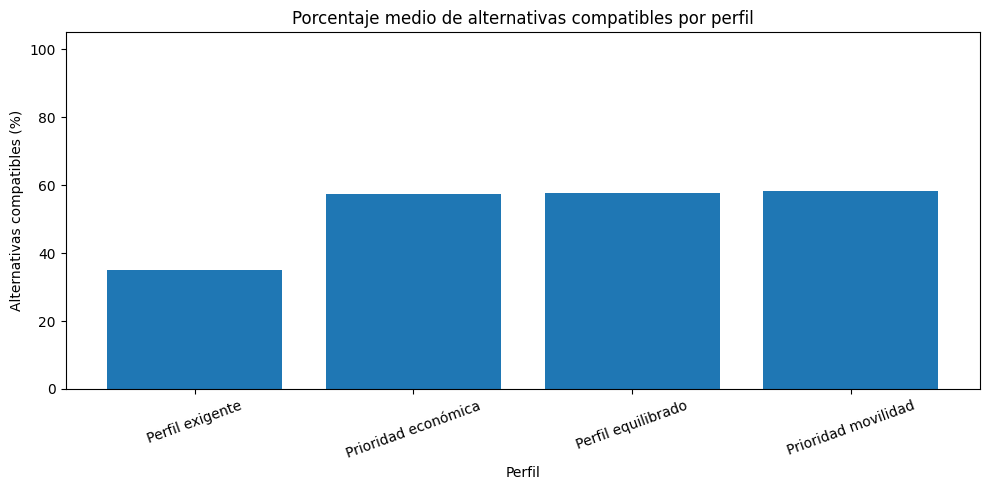

In [8]:
coverage_by_profile = (
    scenario_audit.groupby(
        ["profile_id", "profile_name"],
        as_index=False,
    )
    .agg(
        scenarios=("scenario_id", "nunique"),
        alternatives_total_mean=(
            "alternatives_total",
            "mean",
        ),
        alternatives_feasible_mean=(
            "alternatives_feasible",
            "mean",
        ),
        feasible_percentage_mean=(
            "feasible_percentage",
            "mean",
        ),
        pareto_feasible_mean=(
            "alternatives_pareto_feasible",
            "mean",
        ),
        pareto_feasible_percentage_mean=(
            "pareto_feasible_percentage",
            "mean",
        ),
    )
)

display(coverage_by_profile.round(2))

fig, ax = plt.subplots(figsize=(10, 5))

plot_data = coverage_by_profile.sort_values(
    "feasible_percentage_mean"
)

ax.bar(
    plot_data["profile_name"],
    plot_data["feasible_percentage_mean"],
)
ax.set_title(
    "Porcentaje medio de alternativas compatibles por perfil"
)
ax.set_xlabel("Perfil")
ax.set_ylabel("Alternativas compatibles (%)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 8. Comparación general de métodos

Se estudian cumplimiento, puntuación personalizada, arrepentimiento, eficiencia Pareto y variedad de barrios seleccionados. En puntuación y arrepentimiento, cuanto menor sea el valor, mejor.

In [9]:
method_summary = (
    method_results.groupby(
        ["method_id", "method_name"],
        as_index=False,
        sort=False,
    )
    .agg(
        scenarios=("scenario_id", "nunique"),
        constraint_compliance_rate=(
            "meets_all_constraints",
            "mean",
        ),
        feasible_pareto_rate=(
            "is_pareto_feasible",
            "mean",
        ),
        personalized_score_mean=(
            "personalized_score",
            "mean",
        ),
        regret_mean=(
            "regret_vs_oracle",
            "mean",
        ),
        regret_max=(
            "regret_vs_oracle",
            "max",
        ),
        price_normalized_mean=(
            "evaluation_price_normalized",
            "mean",
        ),
        time_normalized_mean=(
            "evaluation_time_normalized",
            "mean",
        ),
        price_m2_mean=(
            PRICE_COLUMN,
            "mean",
        ),
        commute_minutes_mean=(
            TIME_COLUMN,
            "mean",
        ),
        unique_neighborhoods=(
            "zone_key",
            "nunique",
        ),
    )
)

method_summary[
    "constraint_compliance_percentage"
] = (
    100
    * method_summary[
        "constraint_compliance_rate"
    ]
)

method_summary[
    "feasible_pareto_percentage"
] = (
    100
    * method_summary[
        "feasible_pareto_rate"
    ]
)

display(
    method_summary[
        [
            "method_name",
            "constraint_compliance_percentage",
            "feasible_pareto_percentage",
            "personalized_score_mean",
            "regret_mean",
            "regret_max",
            "price_normalized_mean",
            "time_normalized_mean",
            "unique_neighborhoods",
        ]
    ].round(4)
)

,method_name,constraint_compliance_percentage,feasible_pareto_percentage,personalized_score_mean,regret_mean,regret_max,price_normalized_mean,time_normalized_mean,unique_neighborhoods
0,Más barato,58.3333,58.3333,0.2182,0.1310,0.3771,0.0000,0.4365,1
1,Más rápido,50.0000,50.0000,0.3069,0.2197,0.7114,0.6139,0.0000,3
2,Equilibrio fijo,100.0000,100.0000,0.1044,0.0172,0.1173,0.1864,0.0225,3
3,Búsqueda exhaustiva personalizada,100.0000,100.0000,0.0872,0.0000,0.0000,0.1438,0.1066,5
4,Recomendador Pareto personalizado,100.0000,100.0000,0.0872,0.0000,0.0000,0.1438,0.1066,5


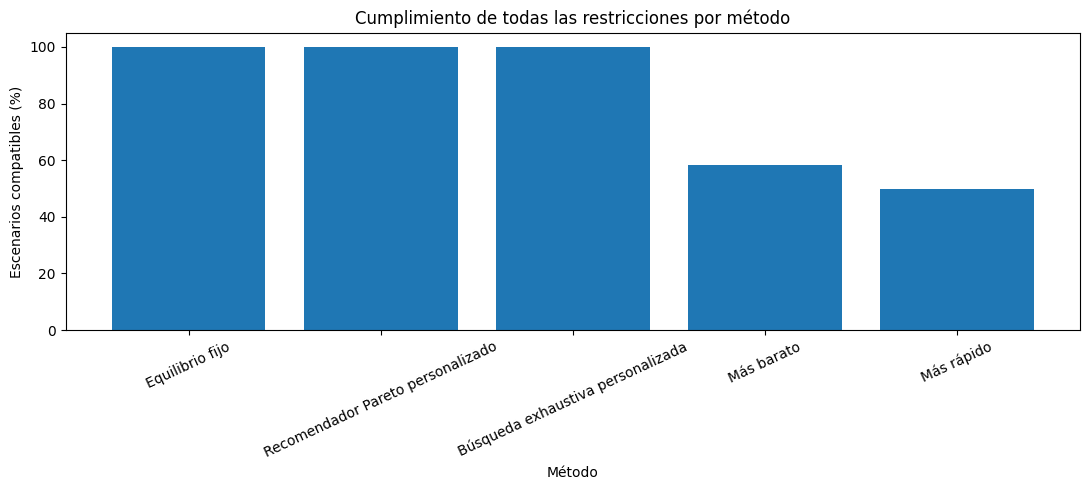

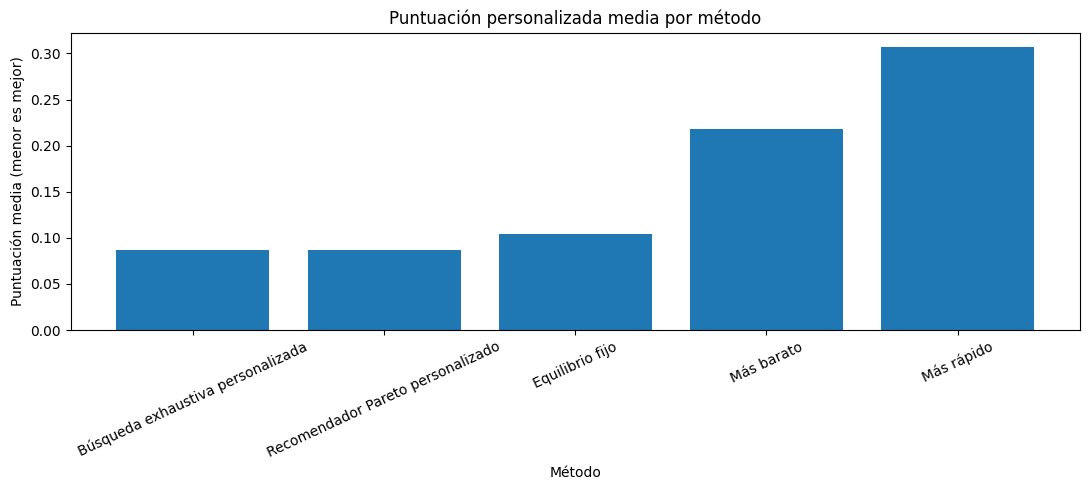

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

plot_data = method_summary.sort_values(
    "constraint_compliance_percentage",
    ascending=False,
)

ax.bar(
    plot_data["method_name"],
    plot_data[
        "constraint_compliance_percentage"
    ],
)
ax.set_title(
    "Cumplimiento de todas las restricciones por método"
)
ax.set_xlabel("Método")
ax.set_ylabel("Escenarios compatibles (%)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))

plot_data = method_summary.sort_values(
    "personalized_score_mean"
)

ax.bar(
    plot_data["method_name"],
    plot_data["personalized_score_mean"],
)
ax.set_title(
    "Puntuación personalizada media por método"
)
ax.set_xlabel("Método")
ax.set_ylabel("Puntuación media (menor es mejor)")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 9. Mejora frente a los baselines

In [11]:
pareto_reference = (
    method_results.loc[
        method_results["method_id"].eq(
            "personalized_pareto"
        ),
        [
            "scenario_id",
            "personalized_score",
        ],
    ]
    .rename(
        columns={
            "personalized_score": "pareto_score"
        }
    )
)

baseline_comparison = (
    method_results.loc[
        method_results["method_id"].isin(
            [
                "cheapest",
                "fastest",
                "fixed_balanced",
            ]
        )
    ]
    .merge(
        pareto_reference,
        on="scenario_id",
        how="left",
        validate="many_to_one",
    )
)

baseline_comparison[
    "score_improvement"
] = (
    baseline_comparison["personalized_score"]
    - baseline_comparison["pareto_score"]
)

baseline_comparison["comparison_result"] = np.select(
    [
        baseline_comparison[
            "score_improvement"
        ] > TOLERANCE,
        baseline_comparison[
            "score_improvement"
        ] < -TOLERANCE,
    ],
    [
        "pareto_better",
        "pareto_worse",
    ],
    default="tie",
)

baseline_improvements = (
    baseline_comparison.groupby(
        ["method_id", "method_name"],
        as_index=False,
        sort=False,
    )
    .agg(
        scenarios=("scenario_id", "nunique"),
        mean_score_improvement=(
            "score_improvement",
            "mean",
        ),
        median_score_improvement=(
            "score_improvement",
            "median",
        ),
        pareto_better_rate=(
            "comparison_result",
            lambda values: (
                values.eq("pareto_better").mean()
            ),
        ),
        tie_rate=(
            "comparison_result",
            lambda values: values.eq("tie").mean(),
        ),
        pareto_worse_rate=(
            "comparison_result",
            lambda values: (
                values.eq("pareto_worse").mean()
            ),
        ),
    )
)

for column in [
    "pareto_better_rate",
    "tie_rate",
    "pareto_worse_rate",
]:
    baseline_improvements[
        column.replace("_rate", "_percentage")
    ] = (
        100 * baseline_improvements[column]
    )

display(
    baseline_improvements[
        [
            "method_name",
            "mean_score_improvement",
            "median_score_improvement",
            "pareto_better_percentage",
            "tie_percentage",
            "pareto_worse_percentage",
        ]
    ].round(4)
)

,method_name,mean_score_improvement,median_score_improvement,pareto_better_percentage,tie_percentage,pareto_worse_percentage
0,Más barato,0.1310,0.1112,83.3333,16.6667,0.0
1,Más rápido,0.2197,0.1729,75.0000,25.0000,0.0
2,Equilibrio fijo,0.0172,0.0000,25.0000,75.0000,0.0


## 10. Validación Pareto frente a búsqueda exhaustiva

La búsqueda exhaustiva revisa todas las alternativas compatibles. El recomendador Pareto revisa únicamente las eficientes. Como ambos objetivos se minimizan y los pesos son no negativos, una alternativa dominada no puede mejorar la puntuación de otra que sea igual o mejor en precio y tiempo.

In [12]:
exhaustive_results = (
    method_results.loc[
        method_results["method_id"].eq(
            "personalized_exhaustive"
        ),
        [
            "scenario_id",
            "zone_key",
            "neighborhood_name",
            "personalized_score",
        ],
    ]
    .rename(
        columns={
            "zone_key": "exhaustive_zone_key",
            "neighborhood_name": "exhaustive_neighborhood",
            "personalized_score": "exhaustive_score",
        }
    )
)

pareto_results = (
    method_results.loc[
        method_results["method_id"].eq(
            "personalized_pareto"
        ),
        [
            "scenario_id",
            "zone_key",
            "neighborhood_name",
            "personalized_score",
            "is_pareto_feasible",
            "dominators_in_feasible_set",
        ],
    ]
    .rename(
        columns={
            "zone_key": "pareto_zone_key",
            "neighborhood_name": "pareto_neighborhood",
            "personalized_score": "pareto_score",
        }
    )
)

pareto_validation = exhaustive_results.merge(
    pareto_results,
    on="scenario_id",
    how="inner",
    validate="one_to_one",
)

pareto_validation["score_difference"] = (
    pareto_validation["pareto_score"]
    - pareto_validation["exhaustive_score"]
)

pareto_validation["same_score"] = (
    pareto_validation[
        "score_difference"
    ].abs()
    <= TOLERANCE
)

pareto_validation["same_neighborhood"] = (
    pareto_validation["pareto_zone_key"]
    == pareto_validation["exhaustive_zone_key"]
)

display(
    pd.Series(
        {
            "scenarios": len(pareto_validation),
            "same_score_percentage": (
                100
                * pareto_validation[
                    "same_score"
                ].mean()
            ),
            "same_neighborhood_percentage": (
                100
                * pareto_validation[
                    "same_neighborhood"
                ].mean()
            ),
            "maximum_absolute_score_difference": (
                pareto_validation[
                    "score_difference"
                ].abs().max()
            ),
            "maximum_dominators": (
                pareto_validation[
                    "dominators_in_feasible_set"
                ].fillna(0)
                .max()
            ),
        },
        name="value",
    ).to_frame()
)

,value
scenarios,12.0
same_score_percentage,100.0
same_neighborhood_percentage,100.0
maximum_absolute_score_difference,0.0
maximum_dominators,0.0


## 11. Cumplimiento por perfil

In [13]:
compliance_by_profile = (
    method_results.groupby(
        [
            "profile_id",
            "profile_name",
            "method_id",
            "method_name",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        price_compliance=(
            "meets_price_limit",
            "mean",
        ),
        time_compliance=(
            "meets_time_limit",
            "mean",
        ),
        reliability_compliance=(
            "meets_reliability_limit",
            "mean",
        ),
        total_compliance=(
            "meets_all_constraints",
            "mean",
        ),
    )
)

for column in [
    "price_compliance",
    "time_compliance",
    "reliability_compliance",
    "total_compliance",
]:
    compliance_by_profile[
        f"{column}_percentage"
    ] = (
        100 * compliance_by_profile[column]
    )

display(
    compliance_by_profile[
        [
            "profile_name",
            "method_name",
            "price_compliance_percentage",
            "time_compliance_percentage",
            "reliability_compliance_percentage",
            "total_compliance_percentage",
        ]
    ].round(2)
)

,profile_name,method_name,price_compliance_percentage,time_compliance_percentage,reliability_compliance_percentage,total_compliance_percentage
0,Prioridad económica,Más barato,100.00,100.00,100.0,100.00
1,Prioridad económica,Más rápido,33.33,100.00,100.0,33.33
2,Prioridad económica,Equilibrio fijo,100.00,100.00,100.0,100.00
3,Prioridad económica,Búsqueda exhaustiva personalizada,100.00,100.00,100.0,100.00
4,Prioridad económica,Recomendador Pareto personalizado,100.00,100.00,100.0,100.00
5,Perfil equilibrado,Más barato,100.00,66.67,100.0,66.67
6,Perfil equilibrado,Más rápido,33.33,100.00,100.0,33.33
7,Perfil equilibrado,Equilibrio fijo,100.00,100.00,100.0,100.00
8,Perfil equilibrado,Búsqueda exhaustiva personalizada,100.00,100.00,100.0,100.00
9,Perfil equilibrado,Recomendador Pareto personalizado,100.00,100.00,100.0,100.00


## 12. Equilibrio entre precio y tiempo

,method_id,method_name,normalized_price_mean,normalized_time_mean,personalized_score_mean
0,cheapest,Más barato,0.0000,0.4365,0.2182
1,fastest,Más rápido,0.6139,0.0000,0.3069
2,fixed_balanced,Equilibrio fijo,0.1864,0.0225,0.1044
3,personalized_exhaustive,Búsqueda exhaustiva personalizada,0.1438,0.1066,0.0872
4,personalized_pareto,Recomendador Pareto personalizado,0.1438,0.1066,0.0872


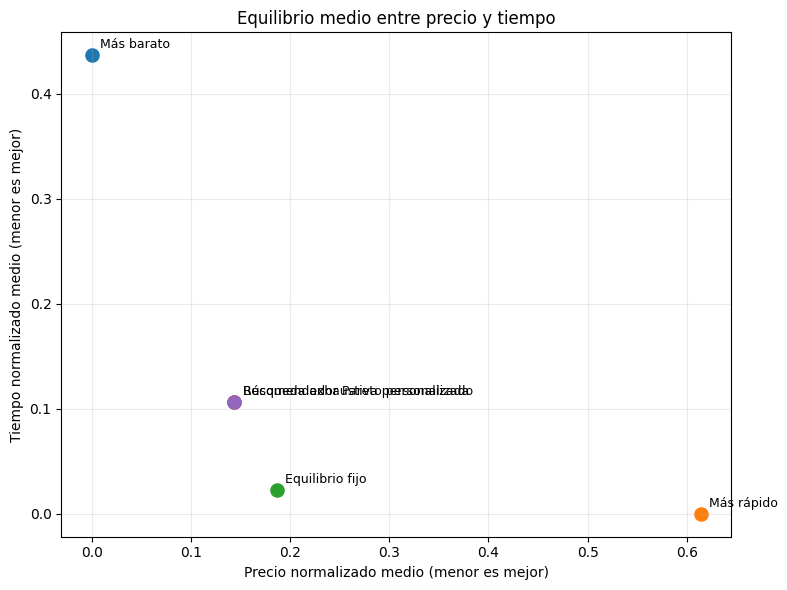

In [14]:
tradeoff_summary = (
    method_results.groupby(
        ["method_id", "method_name"],
        as_index=False,
        sort=False,
    )
    .agg(
        normalized_price_mean=(
            "evaluation_price_normalized",
            "mean",
        ),
        normalized_time_mean=(
            "evaluation_time_normalized",
            "mean",
        ),
        personalized_score_mean=(
            "personalized_score",
            "mean",
        ),
    )
)

display(tradeoff_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 6))

for _, row in tradeoff_summary.iterrows():
    ax.scatter(
        row["normalized_price_mean"],
        row["normalized_time_mean"],
        s=90,
    )
    ax.annotate(
        row["method_name"],
        (
            row["normalized_price_mean"],
            row["normalized_time_mean"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_title(
    "Equilibrio medio entre precio y tiempo"
)
ax.set_xlabel(
    "Precio normalizado medio (menor es mejor)"
)
ax.set_ylabel(
    "Tiempo normalizado medio (menor es mejor)"
)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 13. Diversidad y adaptación

La diversidad no implica por sí sola que un método sea mejor, pero permite comprobar que el sistema no devuelve siempre el mismo barrio. También se compara la similitud de las listas top 5 entre perfiles mediante el índice de Jaccard.

,method_id,method_name,unique_top1_neighborhoods,top1_catalog_coverage_percentage,normalized_selection_entropy,most_frequent_neighborhood,most_frequent_selection_percentage,pareto_top5_catalog_coverage_percentage
0,cheapest,Más barato,1,0.781,0.00,San Cristóbal,100.000,NaN
1,fastest,Más rápido,3,2.344,1.00,Recoletos,33.333,NaN
2,fixed_balanced,Equilibrio fijo,3,2.344,1.00,Puerta del Ángel,33.333,NaN
3,personalized_exhaustive,Búsqueda exhaustiva personalizada,5,3.906,0.96,Puerta del Ángel,25.000,NaN
4,personalized_pareto,Recomendador Pareto personalizado,5,3.906,0.96,Puerta del Ángel,25.000,16.406


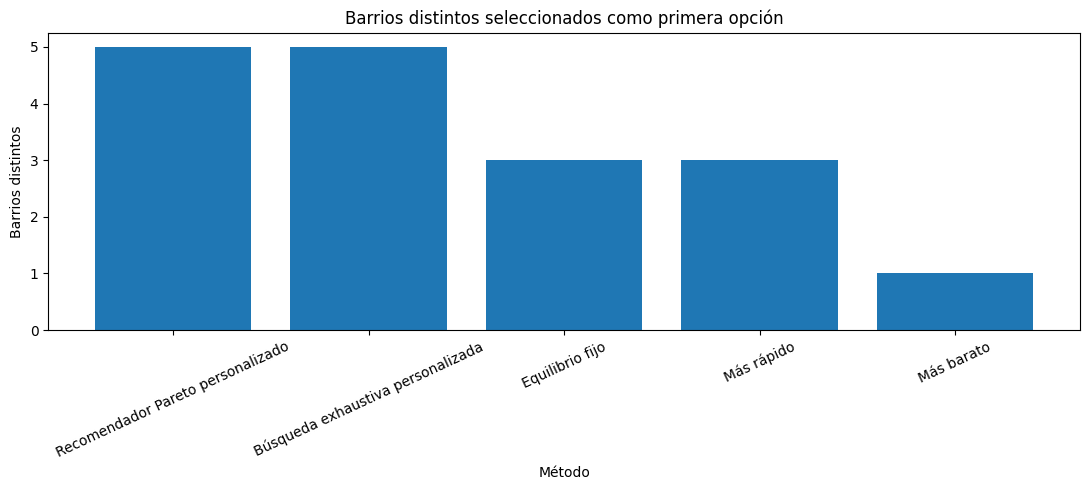

In [15]:
def normalized_entropy(
    values: pd.Series,
) -> float:
    probabilities = (
        values.value_counts(normalize=True)
        .to_numpy(dtype=float)
    )

    if len(probabilities) <= 1:
        return 0.0

    entropy = -np.sum(
        probabilities * np.log(probabilities)
    )

    return float(
        entropy / np.log(len(probabilities))
    )


total_available_neighborhoods = (
    evaluation_data["zone_key"].nunique()
)

diversity_rows = []

for (
    method_id,
    method_name,
), group in method_results.groupby(
    ["method_id", "method_name"],
    sort=False,
):
    unique_neighborhoods = group[
        "zone_key"
    ].nunique()

    diversity_rows.append(
        {
            "method_id": method_id,
            "method_name": method_name,
            "unique_top1_neighborhoods": unique_neighborhoods,
            "top1_catalog_coverage_percentage": (
                100
                * unique_neighborhoods
                / total_available_neighborhoods
            ),
            "normalized_selection_entropy": (
                normalized_entropy(
                    group["zone_key"]
                )
            ),
            "most_frequent_neighborhood": (
                group["neighborhood_name"]
                .value_counts()
                .index[0]
            ),
            "most_frequent_selection_percentage": (
                100
                * group["neighborhood_name"]
                .value_counts(normalize=True)
                .iloc[0]
            ),
        }
    )

diversity_summary = pd.DataFrame(
    diversity_rows
)

pareto_top5_unique = (
    top5_results["zone_key"].nunique()
)

diversity_summary[
    "pareto_top5_catalog_coverage_percentage"
] = np.where(
    diversity_summary["method_id"].eq(
        "personalized_pareto"
    ),
    100
    * pareto_top5_unique
    / total_available_neighborhoods,
    np.nan,
)

display(diversity_summary.round(3))

fig, ax = plt.subplots(figsize=(11, 5))

plot_data = diversity_summary.sort_values(
    "unique_top1_neighborhoods",
    ascending=False,
)

ax.bar(
    plot_data["method_name"],
    plot_data["unique_top1_neighborhoods"],
)
ax.set_title(
    "Barrios distintos seleccionados como primera opción"
)
ax.set_xlabel("Método")
ax.set_ylabel("Barrios distintos")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [16]:
pareto_top1 = (
    method_results.loc[
        method_results["method_id"].eq(
            "personalized_pareto"
        ),
        [
            "destination_id",
            "destination_name",
            "profile_id",
            "profile_name",
            "zone_key",
            "neighborhood_name",
        ],
    ]
    .copy()
)

adaptation_rows = []

for (
    destination_id,
    destination_name,
), destination_top1 in pareto_top1.groupby(
    ["destination_id", "destination_name"],
    sort=True,
):
    profile_lists = {}

    destination_rankings = top5_results[
        top5_results["destination_id"].eq(
            destination_id
        )
    ]

    for profile_id, ranking in (
        destination_rankings.groupby(
            "profile_id",
            sort=True,
        )
    ):
        profile_lists[profile_id] = set(
            ranking["zone_key"].tolist()
        )

    jaccard_values = []

    for profile_a, profile_b in combinations(
        sorted(profile_lists),
        2,
    ):
        set_a = profile_lists[profile_a]
        set_b = profile_lists[profile_b]
        union = set_a | set_b

        if union:
            jaccard_values.append(
                len(set_a & set_b) / len(union)
            )

    unique_top1 = destination_top1[
        "zone_key"
    ].nunique()

    adaptation_rows.append(
        {
            "destination_id": destination_id,
            "destination_name": destination_name,
            "profiles_evaluated": (
                destination_top1[
                    "profile_id"
                ].nunique()
            ),
            "unique_top1_recommendations": unique_top1,
            "top1_changes_between_profiles": (
                unique_top1 > 1
            ),
            "mean_top5_jaccard_similarity": (
                float(np.mean(jaccard_values))
                if jaccard_values
                else np.nan
            ),
        }
    )

profile_adaptation = pd.DataFrame(
    adaptation_rows
)

display(
    pd.Series(
        {
            "destinations": len(profile_adaptation),
            "top1_change_percentage": (
                100
                * profile_adaptation[
                    "top1_changes_between_profiles"
                ].mean()
            ),
            "mean_unique_top1_per_destination": (
                profile_adaptation[
                    "unique_top1_recommendations"
                ].mean()
            ),
            "mean_top5_jaccard_similarity": (
                profile_adaptation[
                    "mean_top5_jaccard_similarity"
                ].mean()
            ),
        },
        name="value",
    ).to_frame()
)

display(profile_adaptation.round(3))

display(
    pareto_top1.pivot(
        index="destination_name",
        columns="profile_name",
        values="neighborhood_name",
    )
)

,value
destinations,3.000000
top1_change_percentage,100.000000
mean_unique_top1_per_destination,2.000000
mean_top5_jaccard_similarity,0.542063


,destination_id,destination_name,profiles_evaluated,unique_top1_recommendations,top1_changes_between_profiles,mean_top5_jaccard_similarity
0,DEST_001,Puerta del Sol,4,2,True,0.389
1,DEST_002,Nuevos Ministerios,4,2,True,0.337
2,DEST_003,UC3M Campus de Leganés,4,2,True,0.900


profile_name,Perfil equilibrado,Perfil exigente,Prioridad económica,Prioridad movilidad
destination_name,,,,
Nuevos Ministerios,Bellas Vistas,Bellas Vistas,Hellín,Bellas Vistas
Puerta del Sol,Puerta del Ángel,Puerta del Ángel,San Cristóbal,Puerta del Ángel
UC3M Campus de Leganés,Buenavista,Buenavista,San Cristóbal,Buenavista


## 14. Ejemplo visual

La figura muestra todos los barrios de un destino, las alternativas compatibles, el frente de Pareto recalculado y la recomendación final. Se pueden cambiar las variables de la primera celda para revisar otros casos.

Destino: Puerta del Sol
Perfil: Perfil equilibrado
Recomendación: Puerta del Ángel


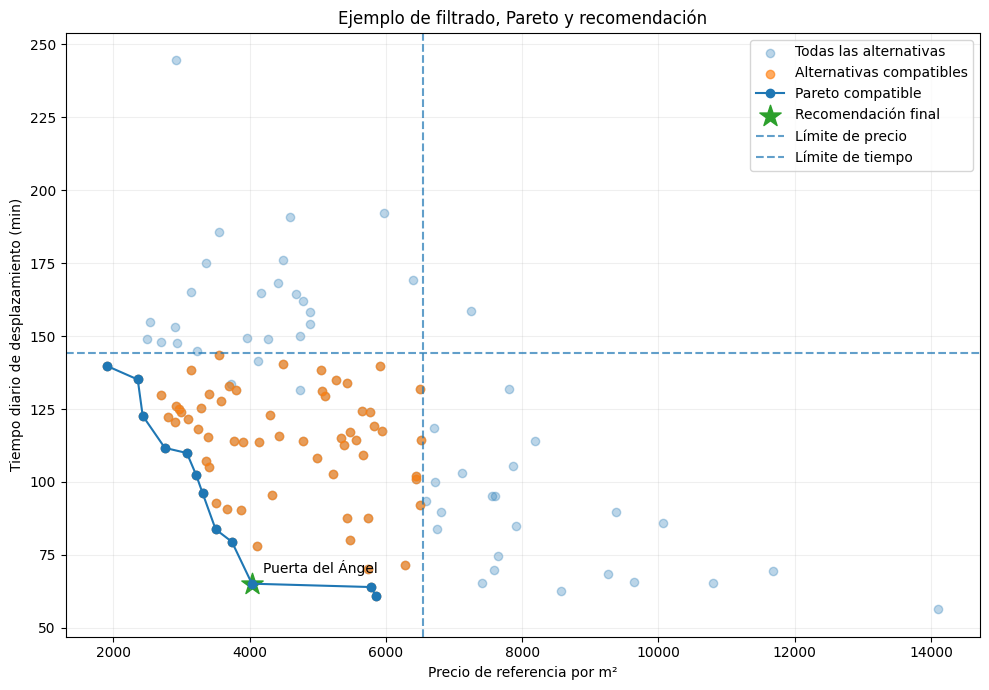

In [17]:
EXAMPLE_DESTINATION_ID = (
    scenario_audit["destination_id"]
    .drop_duplicates()
    .sort_values()
    .iloc[0]
)
EXAMPLE_PROFILE_ID = "balanced"

example_profile = (
    profiles.loc[
        profiles["profile_id"].eq(
            EXAMPLE_PROFILE_ID
        )
    ]
    .iloc[0]
)

example_destination = (
    evaluation_data.loc[
        evaluation_data["destination_id"].eq(
            EXAMPLE_DESTINATION_ID
        )
    ]
    .copy()
    .reset_index(drop=True)
)

example_scored = add_scores(
    example_destination,
    price_weight=float(
        example_profile["price_weight"]
    ),
    time_weight=float(
        example_profile["time_weight"]
    ),
)

example_limits = build_limits(
    example_scored,
    example_profile,
)

example_compatible = (
    example_scored.loc[
        feasible_mask(
            example_scored,
            example_limits,
        )
    ]
    .copy()
)

example_compatible["is_pareto_feasible"] = (
    pareto_mask(example_compatible)
)

example_front = (
    example_compatible.loc[
        example_compatible[
            "is_pareto_feasible"
        ]
    ]
    .sort_values(PRICE_COLUMN)
)

example_selected = select_first(
    example_front,
    ["personalized_score"],
)

print(
    "Destino:",
    example_destination[
        "destination_name"
    ].iloc[0],
)
print(
    "Perfil:",
    example_profile["profile_name"],
)
print(
    "Recomendación:",
    example_selected["neighborhood_name"],
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    example_scored[PRICE_COLUMN],
    example_scored[TIME_COLUMN],
    alpha=0.30,
    label="Todas las alternativas",
)
ax.scatter(
    example_compatible[PRICE_COLUMN],
    example_compatible[TIME_COLUMN],
    alpha=0.65,
    label="Alternativas compatibles",
)
ax.plot(
    example_front[PRICE_COLUMN],
    example_front[TIME_COLUMN],
    marker="o",
    linewidth=1.5,
    label="Pareto compatible",
)
ax.scatter(
    [example_selected[PRICE_COLUMN]],
    [example_selected[TIME_COLUMN]],
    marker="*",
    s=260,
    label="Recomendación final",
)
ax.annotate(
    example_selected["neighborhood_name"],
    (
        example_selected[PRICE_COLUMN],
        example_selected[TIME_COLUMN],
    ),
    xytext=(8, 8),
    textcoords="offset points",
)
ax.axvline(
    example_limits["max_price_m2"],
    linestyle="--",
    alpha=0.7,
    label="Límite de precio",
)
ax.axhline(
    example_limits["max_commute_minutes"],
    linestyle="--",
    alpha=0.7,
    label="Límite de tiempo",
)

ax.set_title(
    "Ejemplo de filtrado, Pareto y recomendación"
)
ax.set_xlabel("Precio de referencia por m²")
ax.set_ylabel("Tiempo diario de desplazamiento (min)")
ax.legend()
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

## 15. Conexión con el notebook 10

Se localizan automáticamente archivos relacionados con robustez, perturbaciones o sensibilidad. Esta parte no recalcula los experimentos anteriores: deja registrada su presencia para facilitar la revisión conjunta.

In [18]:
robustness_candidates = sorted(
    {
        *RESULTS_DIR.glob("*robust*.csv"),
        *RESULTS_DIR.glob("*perturb*.csv"),
        *RESULTS_DIR.glob("*stability*.csv"),
        *RESULTS_DIR.glob("*sensitivity*.csv"),
    }
)

robustness_inventory_rows = []

for path in robustness_candidates:
    try:
        sample = pd.read_csv(
            path,
            nrows=5,
        )
        robustness_inventory_rows.append(
            {
                "file": path.name,
                "rows_sampled": len(sample),
                "columns": ", ".join(
                    sample.columns.tolist()
                ),
                "readable": True,
            }
        )
    except Exception as exc:
        robustness_inventory_rows.append(
            {
                "file": path.name,
                "rows_sampled": 0,
                "columns": "",
                "readable": False,
                "error": str(exc),
            }
        )

robustness_inventory = pd.DataFrame(
    robustness_inventory_rows
)

if robustness_inventory.empty:
    print(
        "No se han encontrado archivos con nombres "
        "relacionados con robustez o sensibilidad."
    )
else:
    display(robustness_inventory)

,file,rows_sampled,columns,readable
0,evaluation_constraint_robustness.csv,5,"destination_id, destination_name, profile_id, profile_name, price_quantile, time_quantile, max_price_m2, max_commute_daily_minutes, eligible_alternatives, feasible, top1_zone_k...",True
1,evaluation_constraint_robustness_summary.csv,5,"destination_id, destination_name, profile_id, profile_name, evaluated_scenarios, feasible_scenarios, mean_eligible_alternatives, minimum_eligible_alternatives, base_top1_retent...",True
2,evaluation_noise_robustness_summary.csv,5,"destination_id, destination_name, profile_id, profile_name, noise_level, iterations, base_top1_zone_key, base_top1_neighborhood_name, base_top1_retention_rate, base_top1_in_top...",True
3,evaluation_weight_stability_grid.csv,5,"destination_id, destination_name, price_weight, time_weight, top1_zone_key, top1_neighborhood_name, top1_price_m2, top1_commute_daily_minutes, top_k_zone_keys, adjacent_jaccard...",True
4,evaluation_weight_stability_intervals.csv,5,"destination_id, destination_name, top1_zone_key, top1_neighborhood_name, price_weight_min, price_weight_max, evaluated_points, interval_width",True
5,evaluation_weight_stability_summary.csv,3,"destination_id, destination_name, evaluated_weight_points, unique_top1_neighborhoods, top1_transitions, mean_adjacent_jaccard_at_k, minimum_adjacent_jaccard_at_k, dominant_top1...",True
6,pareto_weight_sensitivity.csv,5,"destination_id, destination_name, price_weight, time_weight, zone_key, neighborhood_name, district_name, price_eur_m2, commute_daily_minutes, sensitivity_score, selection_block",True
7,recommendation_weight_sensitivity_all_destinations.csv,5,"destination_id, destination_name, price_weight, time_weight, zone_key, neighborhood_name, district_name, price_m2_for_recommender, commute_daily_minutes, preference_score",True
8,recommendation_weight_sensitivity_example.csv,5,"destination_id, destination_name, price_weight, time_weight, zone_key, neighborhood_name, district_name, price_m2_for_recommender, commute_daily_minutes, preference_score",True
9,recommendation_weight_sensitivity_intervals.csv,5,"interval_id, destination_id, destination_name, min_price_weight, max_price_weight, min_time_weight, max_time_weight, zone_key, neighborhood_name, district_name, price_eur_m2, c...",True


## 16. Validaciones finales

El notebook se detiene si falta algún escenario, aparecen duplicados, el recomendador incumple restricciones, selecciona alternativas dominadas o pierde puntuación frente a la búsqueda exhaustiva.

In [19]:
expected_scenarios = (
    evaluation_data["destination_id"].nunique()
    * profiles["profile_id"].nunique()
)
expected_method_rows = (
    expected_scenarios
    * len(METHOD_LABELS)
)

pareto_method_results = (
    method_results.loc[
        method_results["method_id"].eq(
            "personalized_pareto"
        )
    ]
)

duplicate_method_results = (
    method_results.duplicated(
        ["scenario_id", "method_id"],
        keep=False,
    )
)

validation_report = pd.DataFrame(
    [
        {
            "validation_id": "scenario_count",
            "description": (
                "Se han evaluado todos los destinos "
                "con todos los perfiles."
            ),
            "passed": (
                len(scenario_audit)
                == expected_scenarios
            ),
            "detail": (
                f"Esperados: {expected_scenarios}; "
                f"obtenidos: {len(scenario_audit)}."
            ),
        },
        {
            "validation_id": "method_result_count",
            "description": (
                "Cada escenario tiene un resultado "
                "por método."
            ),
            "passed": (
                len(method_results)
                == expected_method_rows
            ),
            "detail": (
                f"Esperados: {expected_method_rows}; "
                f"obtenidos: {len(method_results)}."
            ),
        },
        {
            "validation_id": "no_duplicates",
            "description": (
                "No hay resultados duplicados."
            ),
            "passed": (
                not duplicate_method_results.any()
            ),
            "detail": (
                f"Duplicados: "
                f"{int(duplicate_method_results.sum())}."
            ),
        },
        {
            "validation_id": "all_scenarios_feasible",
            "description": (
                "Todos los escenarios tienen "
                "alternativas compatibles."
            ),
            "passed": bool(
                scenario_audit[
                    "alternatives_feasible"
                ].gt(0).all()
            ),
            "detail": (
                "Mínimo compatible: "
                f"{scenario_audit['alternatives_feasible'].min()}."
            ),
        },
        {
            "validation_id": "pareto_meets_constraints",
            "description": (
                "El recomendador Pareto cumple "
                "todas las restricciones."
            ),
            "passed": bool(
                pareto_method_results[
                    "meets_all_constraints"
                ].all()
            ),
            "detail": (
                "Incumplimientos: "
                f"{int((~pareto_method_results['meets_all_constraints']).sum())}."
            ),
        },
        {
            "validation_id": "pareto_is_efficient",
            "description": (
                "Todas las recomendaciones Pareto "
                "son eficientes."
            ),
            "passed": bool(
                pareto_method_results[
                    "is_pareto_feasible"
                ].all()
            ),
            "detail": (
                "No eficientes: "
                f"{int((~pareto_method_results['is_pareto_feasible']).sum())}."
            ),
        },
        {
            "validation_id": "pareto_matches_exhaustive",
            "description": (
                "Pareto alcanza la misma puntuación "
                "que la búsqueda exhaustiva."
            ),
            "passed": bool(
                pareto_validation[
                    "same_score"
                ].all()
            ),
            "detail": (
                "Diferencia máxima: "
                f"{pareto_validation['score_difference'].abs().max():.12f}."
            ),
        },
        {
            "validation_id": "pareto_zero_dominators",
            "description": (
                "Ninguna recomendación Pareto "
                "tiene dominadores compatibles."
            ),
            "passed": bool(
                pareto_method_results[
                    "dominators_in_feasible_set"
                ].fillna(0)
                .eq(0)
                .all()
            ),
            "detail": (
                "Máximo de dominadores: "
                f"{pareto_method_results['dominators_in_feasible_set'].fillna(0).max():.0f}."
            ),
        },
    ]
)

display(validation_report)

failed_validations = validation_report.loc[
    ~validation_report["passed"]
]

if not failed_validations.empty:
    display(failed_validations)
    raise AssertionError(
        "La evaluación final no supera "
        "todas las validaciones."
    )

print("Todas las validaciones finales se han superado.")

,validation_id,description,passed,detail
0,scenario_count,Se han evaluado todos los destinos con todos los perfiles.,True,Esperados: 12; obtenidos: 12.
1,method_result_count,Cada escenario tiene un resultado por método.,True,Esperados: 60; obtenidos: 60.
2,no_duplicates,No hay resultados duplicados.,True,Duplicados: 0.
3,all_scenarios_feasible,Todos los escenarios tienen alternativas compatibles.,True,Mínimo compatible: 42.
4,pareto_meets_constraints,El recomendador Pareto cumple todas las restricciones.,True,Incumplimientos: 0.
5,pareto_is_efficient,Todas las recomendaciones Pareto son eficientes.,True,No eficientes: 0.
6,pareto_matches_exhaustive,Pareto alcanza la misma puntuación que la búsqueda exhaustiva.,True,Diferencia máxima: 0.000000000000.
7,pareto_zero_dominators,Ninguna recomendación Pareto tiene dominadores compatibles.,True,Máximo de dominadores: 0.


Todas las validaciones finales se han superado.


## 17. Exportación

In [20]:
exports = {
    "scenarios": scenario_audit,
    "method_results": method_results,
    "method_summary": method_summary,
    "top5": top5_results,
    "baseline_improvements": baseline_improvements,
    "diversity": diversity_summary,
    "profile_adaptation": profile_adaptation,
    "validation": validation_report,
}

for name, dataframe in exports.items():
    dataframe.to_csv(
        OUTPUT_PATHS[name],
        index=False,
        encoding="utf-8-sig",
    )

print("Archivos generados:")

for path in OUTPUT_PATHS.values():
    print(
        "-",
        path.relative_to(PROJECT_ROOT),
    )

Archivos generados:
- data\results\final_evaluation_scenarios.csv
- data\results\final_evaluation_method_results.csv
- data\results\final_evaluation_method_summary.csv
- data\results\final_evaluation_top5_rankings.csv
- data\results\final_evaluation_baseline_improvements.csv
- data\results\final_evaluation_diversity_summary.csv
- data\results\final_evaluation_profile_adaptation.csv
- data\results\final_evaluation_validation.csv


## 18. Resumen automático

In [21]:
pareto_summary_row = (
    method_summary.loc[
        method_summary["method_id"].eq(
            "personalized_pareto"
        )
    ]
    .iloc[0]
)

best_baseline_row = (
    method_summary.loc[
        method_summary["method_id"].isin(
            [
                "cheapest",
                "fastest",
                "fixed_balanced",
            ]
        )
    ]
    .sort_values(
        "personalized_score_mean"
    )
    .iloc[0]
)

adaptation_rate = float(
    profile_adaptation[
        "top1_changes_between_profiles"
    ].mean()
)

mean_top5_similarity = float(
    profile_adaptation[
        "mean_top5_jaccard_similarity"
    ].mean()
)

display(
    Markdown(
        f"""
### Lectura final

Se han evaluado **{len(scenario_audit)} escenarios**, formados por **{evaluation_data['destination_id'].nunique()} destinos** y **{profiles['profile_id'].nunique()} perfiles**.

El recomendador Pareto personalizado cumple todas las restricciones en el **{pareto_summary_row['constraint_compliance_percentage']:.2f} %** de los escenarios. Su arrepentimiento máximo frente a la búsqueda exhaustiva es de **{pareto_summary_row['regret_max']:.12f}**, por lo que la reducción mediante Pareto no ha eliminado ninguna solución con mejor puntuación.

Entre las estrategias simples, el mejor resultado medio corresponde a **{best_baseline_row['method_name']}**, con una puntuación de **{best_baseline_row['personalized_score_mean']:.4f}**, frente a **{pareto_summary_row['personalized_score_mean']:.4f}** del recomendador personalizado.

La primera recomendación cambia entre perfiles en el **{100 * adaptation_rate:.2f} %** de los destinos. La similitud media entre listas top 5 es de **{mean_top5_similarity:.3f}**.
"""
    )
)


### Lectura final

Se han evaluado **12 escenarios**, formados por **3 destinos** y **4 perfiles**.

El recomendador Pareto personalizado cumple todas las restricciones en el **100.00 %** de los escenarios. Su arrepentimiento máximo frente a la búsqueda exhaustiva es de **0.000000000000**, por lo que la reducción mediante Pareto no ha eliminado ninguna solución con mejor puntuación.

Entre las estrategias simples, el mejor resultado medio corresponde a **Equilibrio fijo**, con una puntuación de **0.1044**, frente a **0.0872** del recomendador personalizado.

La primera recomendación cambia entre perfiles en el **100.00 %** de los destinos. La similitud media entre listas top 5 es de **0.542**.


## 19. Conclusiones

La comparación con métodos simples permite comprobar que elegir únicamente el barrio más barato o el más rápido no siempre respeta el conjunto de necesidades del usuario. El equilibrio fijo mejora esa situación, pero aplica las mismas preferencias a todas las personas.

El recomendador completo combina restricciones, eficiencia multiobjetivo y ponderaciones personalizadas. La comparación con la búsqueda exhaustiva permite verificar que recalcular el frente de Pareto reduce el conjunto de alternativas sin perder la mejor solución compatible según la función de puntuación utilizada.

El análisis de diversidad y adaptación muestra si los resultados cambian realmente al modificar el destino o el perfil. De esta forma se comprueba que el sistema no se limita a devolver un ranking general de barrios.

Los resultados deben interpretarse como una evaluación experimental con datos agregados. No sustituyen una validación con usuarios reales ni una valoración de viviendas concretas. Aun así, permiten cerrar el desarrollo con una comprobación reproducible, trazable y alineada con el objetivo principal del TFG: encontrar barrios que ofrezcan un equilibrio razonable entre coste de vivienda y tiempo de desplazamiento.